# Shrink the Matrix — a quantitative teardown \U0001F52C
### Ledoit-Wolf intensities · eigenvalue spectra · rolling out-of-sample minimum variance · paired tests

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two
cross-sections are run side by side throughout — eleven sectors and forty names — because the
whole question is **rows per parameter**, and a study that only ran the comfortable case would
conclude, wrongly, that shrinkage is a solution in search of a problem.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from shrinkage import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
sectors = [s for s in data.SECTORS if rets[s].notna().sum() > 1500]
names = [s for s in data.NAMES if rets[s].notna().sum() > 3000]
print(f"as-of {data.AS_OF}")
for tag, cols in (("sectors", sectors), ("names", names)):
    p = len(cols) * (len(cols) + 1) // 2
    print(f"  {tag:8s} {len(cols):3d} assets -> {p:4d} covariance parameters, "
          f"{252 / p:.2f} rows per parameter in a one-year window")

as-of 2026-06-30
  sectors   11 assets ->   66 covariance parameters, 3.82 rows per parameter in a one-year window
  names     40 assets ->  820 covariance parameters, 0.31 rows per parameter in a one-year window


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | On the wide cross-section (40 names, 820 covariance parameters, 252 rows of history) the sample matrix promises 9.81% annualised volatility and delivers **13.07%** — it is **25%** optimistic, and its median condition number is **335** against 162 for the shrunk version. On the eleven-sector sleeve, where rows outnumber parameters 4 to one, the same optimism is only 11% — the problem is arithmetic, not equities. |
| **Usefulness** | Fragile | **Ledoit-Wolf -> identity** cut realised volatility from 13.07% to **12.49%** — a **4%** saving, paired *t* = **+6.51** across 61 rebalances, winning 16% of them. It also turns over 1.14 against 1.54 per rebalance and holds a maximum weight of 24% against 32%. Three lines of algebra, no tuning parameter, no look-ahead. |

> \U0001F4A1 **In plain words.** The question is never "is the estimator unbiased" but "what
> happens when I invert it", and the answer depends on one ratio: observations per parameter.

## 1 · The claim, steelmanned

- **H₁.** The sample covariance matrix's in-sample minimum-variance volatility understates the
  realised one, by an amount that grows with N/T.
- **H₂.** Shrinkage toward a structured target reduces realised volatility out of sample, with
  the analytic intensity and no tuning.
- **H₃.** The constant-correlation target beats the identity on equities, because average
  correlation is a real feature of the data.
- **H₄.** A long-only constraint captures much of the same benefit for free.

## 2 · The protocol

Rolling window, quarterly re-estimation, one day of execution lag, 5 bps a rebalance, and every
comparison **paired** on (window, holding period). The simulation section scores the same
estimators against a covariance matrix that is known exactly, at four sample sizes, so the
real-data ordering can be checked against a case with an answer.

## 3 · The teardown

### 3.1 The eigenvalue spectrum — where the error lives

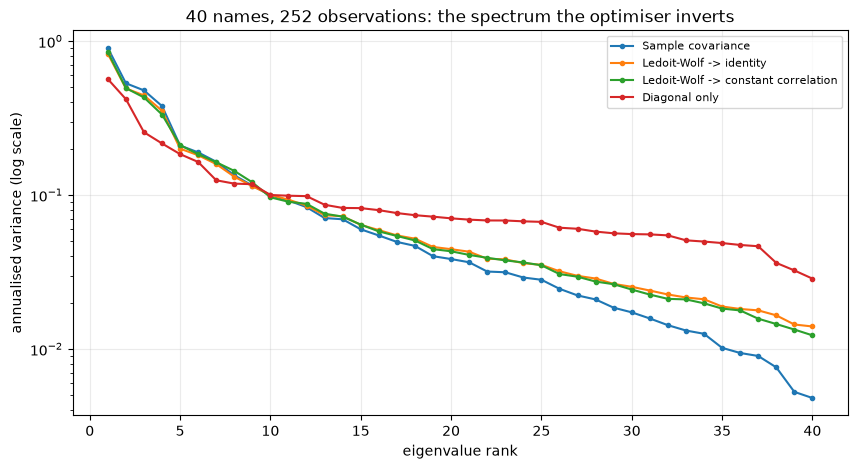

,max,min,top_share,n_below_1pct
Sample covariance,0.0036,0.0000,0.2163,4.0000
Ledoit-Wolf -> identity,0.0033,0.0001,0.1986,0.0000
Ledoit-Wolf -> constant correlation,0.0034,0.0000,0.2035,0.0000
Diagonal only,0.0022,0.0001,0.1359,0.0000


In [3]:
last = rets[names].dropna(how="any").iloc[-252:].to_numpy()
spectra = {}
for m in st.ESTIMATORS:
    C, delta = st.estimate(last, m)
    w = np.sort(np.linalg.eigvalsh(C))[::-1]
    spectra[st.ESTIMATOR_LABEL[m]] = w * 252
fig, ax = plt.subplots(figsize=(10, 5))
for k, w in spectra.items():
    ax.semilogy(range(1, len(w) + 1), np.maximum(w, 1e-12), marker=".", label=k)
ax.set_xlabel("eigenvalue rank"); ax.set_ylabel("annualised variance (log scale)")
ax.set_title(f"{len(names)} names, 252 observations: the spectrum the optimiser inverts")
ax.legend(fontsize=8)
plt.show()
pd.DataFrame({k: st.eigen_spread(st.estimate(last, m)[0])
              for m, k in zip(st.ESTIMATORS, spectra)}).T.round(6)

> \U0001F4A1 **In plain words.** Look at the right-hand end. The sample matrix's smallest
> eigenvalues are orders of magnitude below everything else — directions in which it believes
> a portfolio would have almost no risk at all. The optimiser goes straight there.

### 3.2 The intensity the estimator chooses for itself

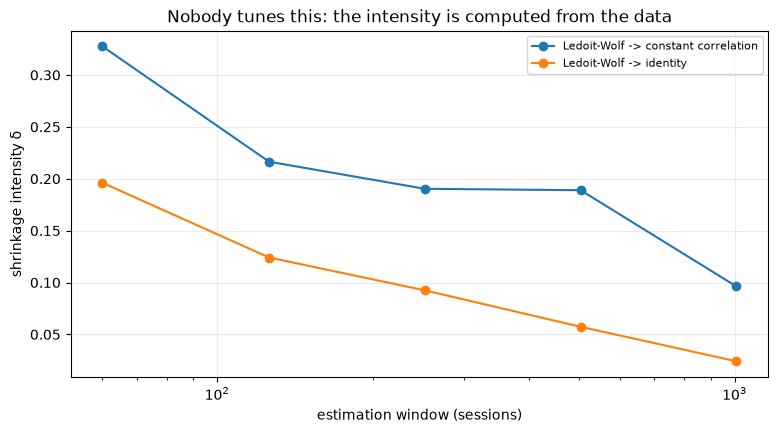

,window,rows/param,estimator,delta,condition
0,60,0.0732,Ledoit-Wolf -> identity,0.1961,45.5864
1,60,0.0732,Ledoit-Wolf -> constant correlation,0.3276,87.3048
2,126,0.1537,Ledoit-Wolf -> identity,0.1241,59.1862
3,126,0.1537,Ledoit-Wolf -> constant correlation,0.2164,80.6620
4,252,0.3073,Ledoit-Wolf -> identity,0.0924,59.1933
5,252,0.3073,Ledoit-Wolf -> constant correlation,0.1903,69.2484
6,504,0.6146,Ledoit-Wolf -> identity,0.0573,102.6022
7,504,0.6146,Ledoit-Wolf -> constant correlation,0.1890,91.8660
8,1008,1.2293,Ledoit-Wolf -> identity,0.0241,108.0095
9,1008,1.2293,Ledoit-Wolf -> constant correlation,0.0962,107.7060


In [4]:
rows = []
sub = rets[names].dropna(how="any")
for window in (60, 126, 252, 504, 1008):
    X = sub.iloc[-window:].to_numpy()
    for m in ("identity", "constant_corr"):
        C, delta = st.estimate(X, m)
        rows.append({"window": window, "rows/param": window / (len(names) * (len(names) + 1) / 2),
                     "estimator": st.ESTIMATOR_LABEL[m], "delta": delta,
                     "condition": st.condition_number(C)})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, g in d.groupby("estimator"):
    ax.plot(g["window"], g["delta"], marker="o", label=name)
ax.set_xscale("log"); ax.set_xlabel("estimation window (sessions)")
ax.set_ylabel("shrinkage intensity δ"); ax.legend(fontsize=8)
ax.set_title("Nobody tunes this: the intensity is computed from the data")
plt.show()
d.round(4)

### 3.3 The walk-forward scoreboard, both cross-sections

In [5]:
out = {}
for tag, cols in (("sectors", sectors), ("names", names)):
    wf = st.walk_forward(rets[cols].dropna(how="any"), window=252, step=63, cost_bps=5.0)
    out[tag] = (wf, st.summarise(wf))
    print(f"--- {tag} ---")
    print(out[tag][1][["delta", "promised_vol", "realised_vol", "optimism", "turnover",
                       "max_weight", "condition"]].round(4).to_string())
    print()
for tag in out:
    wf, s = out[tag]
    best = s.drop(index=["sample"])["realised_vol"].idxmin()
    p = st.paired_vol_test(wf, "sample", best)
    print(f"{tag}: best = {st.ESTIMATOR_LABEL[best]}, mean vol difference {p['diff']:+.3%}, "
          f"t {p['t']:+.2f}, wins {p['win_rate']:.0%} of {p['n']}")

--- sectors ---
               delta  promised_vol  realised_vol  optimism  turnover  max_weight  condition
method                                                                                     
sample        0.0000        0.1254        0.1404   -0.1069    0.9074      0.6231    80.8202
identity      0.0467        0.1316        0.1366   -0.0363    0.6604      0.5117    52.9776
constant_corr 0.4822        0.1269        0.1534   -0.1733    0.6129      0.5584    44.3494
diagonal      1.0000        0.0618        0.1503   -0.5888    0.1089      0.1722     4.1042



--- names ---
               delta  promised_vol  realised_vol  optimism  turnover  max_weight  condition
method                                                                                     
sample        0.0000        0.0981        0.1307   -0.2492    1.5378      0.3163   334.6828
identity      0.0578        0.1017        0.1249   -0.1853    1.1394      0.2415   162.4554
constant_corr 0.3846        0.1000        0.1318   -0.2415    0.9144      0.2807   143.7027
diagonal      1.0000        0.0376        0.1400   -0.7314    0.1187      0.0669    13.6253

sectors: best = Ledoit-Wolf -> identity, mean vol difference +0.389%, t +1.57, wins 29% of 28
names: best = Ledoit-Wolf -> identity, mean vol difference +0.582%, t +6.51, wins 16% of 61


### 3.4 Volatility through time, not just on average

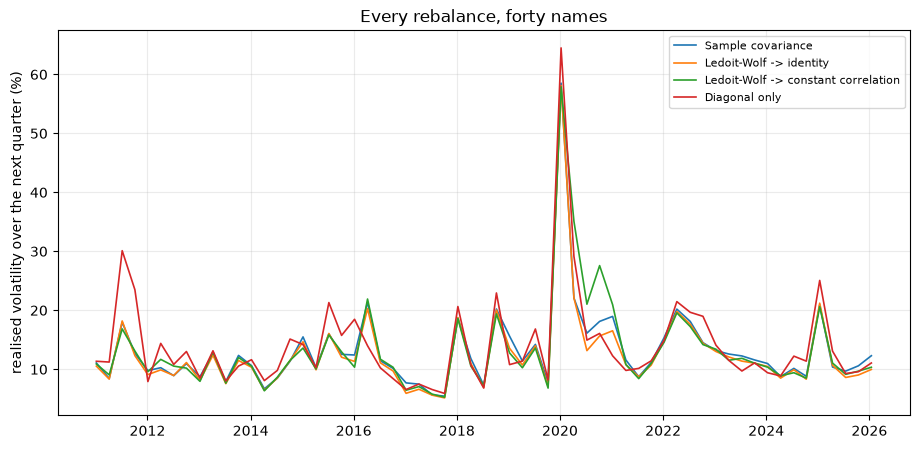

method  constant_corr  diagonal  identity  sample
count         61.0000   61.0000   61.0000 61.0000
mean          13.1800   14.0000   12.4900 13.0700
std            7.9000    8.5200    7.1900  7.1900
min            5.2600    5.9000    5.1500  5.4400
25%            9.4100    9.7000    8.9500  9.6900
50%           10.9700   11.3900   10.9700 11.4400
75%           13.6000   15.1200   13.9800 15.3200
max           57.9100   64.5000   58.1000 58.5200


In [6]:
wf = out["names"][0]
piv = wf.pivot(index="date", columns="method", values="realised_vol")
fig, ax = plt.subplots(figsize=(11, 5))
for m in st.ESTIMATORS:
    ax.plot(piv.index, piv[m] * 100, lw=1.2, label=st.ESTIMATOR_LABEL[m])
ax.set_ylabel("realised volatility over the next quarter (%)")
ax.set_title("Every rebalance, forty names")
ax.legend(fontsize=8)
plt.show()
print((piv * 100).describe().round(2).to_string())

### 3.5 The constraint that acts like shrinkage

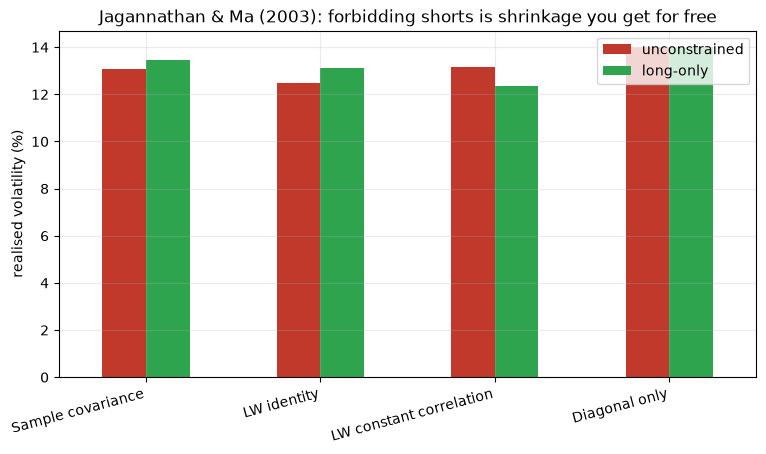

,unconstrained,long-only
Sample covariance,0.1307,0.1345
LW identity,0.1249,0.1310
LW constant correlation,0.1318,0.1236
Diagonal only,0.1400,0.1400


In [7]:
lo = st.summarise(st.walk_forward(rets[names].dropna(how="any"), window=252,
                                  step=63, long_only=True, cost_bps=5.0))
un = out["names"][1]
comp = pd.DataFrame({"unconstrained": un["realised_vol"], "long-only": lo["realised_vol"]})
comp.index = [st.ESTIMATOR_LABEL[m].replace("Ledoit-Wolf -> ", "LW ") for m in comp.index]
fig, ax = plt.subplots(figsize=(9, 4.5))
(comp * 100).plot.bar(ax=ax, color=["#c0392b", "#2ea44f"])
ax.set_ylabel("realised volatility (%)"); ax.legend(title="")
ax.set_title("Jagannathan & Ma (2003): forbidding shorts is shrinkage you get for free")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()
comp.round(4)

### 3.6 Against a known truth

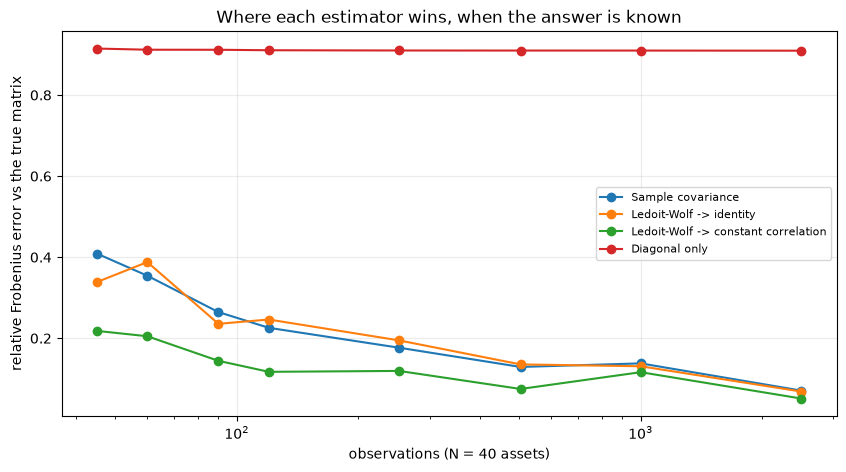

,T/N,Sample covariance,Ledoit-Wolf -> identity,Ledoit-Wolf -> constant correlation,Diagonal only
T,,,,,
45,1.1250,0.4090,0.3390,0.2180,0.9150
60,1.5000,0.3540,0.3880,0.2050,0.9120
90,2.2500,0.2650,0.2360,0.1440,0.9120
120,3.0000,0.2260,0.2460,0.1170,0.9110
252,6.3000,0.1770,0.1950,0.1190,0.9100
504,12.6000,0.1290,0.1350,0.0750,0.9100
1000,25.0000,0.1380,0.1310,0.1160,0.9100
2500,62.5000,0.0710,0.0680,0.0510,0.9090


In [8]:
rng = np.random.default_rng(975)
rows = []
for n_obs in (45, 60, 90, 120, 252, 504, 1000, 2500):
    n_assets, rho, vol = 40, 0.35, 0.02
    f = rng.normal(0, vol, n_obs)
    X = np.outer(f, np.full(n_assets, np.sqrt(rho))) +         rng.normal(0, vol * np.sqrt(1 - rho), (n_obs, n_assets))
    truth = (vol ** 2) * (rho * np.ones((n_assets, n_assets)) + (1 - rho) * np.eye(n_assets))
    row = {"T": n_obs, "T/N": n_obs / n_assets}
    for m in st.ESTIMATORS:
        row[st.ESTIMATOR_LABEL[m]] = st.frobenius_error(st.estimate(X, m)[0], truth)
    rows.append(row)
d = pd.DataFrame(rows).set_index("T")
fig, ax = plt.subplots(figsize=(10, 5))
for c in d.columns.drop("T/N"):
    ax.plot(d.index, d[c], marker="o", label=c)
ax.set_xscale("log"); ax.set_xlabel("observations (N = 40 assets)")
ax.set_ylabel("relative Frobenius error vs the true matrix")
ax.legend(fontsize=8); ax.set_title("Where each estimator wins, when the answer is known")
plt.show()
d.round(3)

## 4 · The verdict

In [9]:
summary = {}
for tag, (wf, s) in out.items():
    best = s.drop(index=["sample"])["realised_vol"].idxmin()
    p = st.paired_vol_test(wf, "sample", best)
    summary[tag] = {"sample vol": s.loc["sample", "realised_vol"],
                    "best vol": s.loc[best, "realised_vol"],
                    "saving": 1 - s.loc[best, "realised_vol"] / s.loc["sample", "realised_vol"],
                    "paired t": p["t"], "sample optimism": s.loc["sample", "optimism"],
                    "best": st.ESTIMATOR_LABEL[best]}
pd.DataFrame(summary).T.round(4)

,sample vol,best vol,saving,paired t,sample optimism,best
sectors,0.1404,0.1366,0.0277,1.5739,-0.1069,Ledoit-Wolf -> identity
names,0.1307,0.1249,0.0445,6.5051,-0.2492,Ledoit-Wolf -> identity


## 5 · Going further

- **Nonlinear shrinkage** (Ledoit & Wolf 2017) and **eigenvalue clipping** (Laloux et al. 1999)
  are the two standard upgrades, and they are close cousins.
- **Factor models** (a covariance matrix built from exposures rather than from returns) are
  shrinkage with an economic story attached.
- **1/N** is the benchmark that refuses to die; run it against everything above and report the
  result honestly — study 171 does.